# 3.6 Resampling and Permutation Tests
Imagine reshuffling a deck of cards to re-deal a game and see if the original win was luck, or re-running a race with random lane assignments to check if one runner truly dominates—that’s what resampling and permutation tests are about! These non-parametric methods let you test hypotheses flexibly, even with small or unusual data, by simulating new possibilities. It’s like giving your data a second chance to tell its story!

## What Are Resampling and Permutation Tests?

- **Resampling**: Reusing data with techniques like bootstrapping or permutations to estimate variability and test hypotheses without strict assumptions.
- **Permutation Test**: Randomly reassigns data labels (e.g., group A vs. B) to create a distribution under the null hypothesis, then compares the original statistic to this distribution.

Unlike t-tests, these methods don’t assume normal distributions, making them ideal for small or skewed datasets. We’ll generate custom permutation data to compare two groups’ scores using Python:

Original Mean Difference: 1.03
P-Value: 0.7170


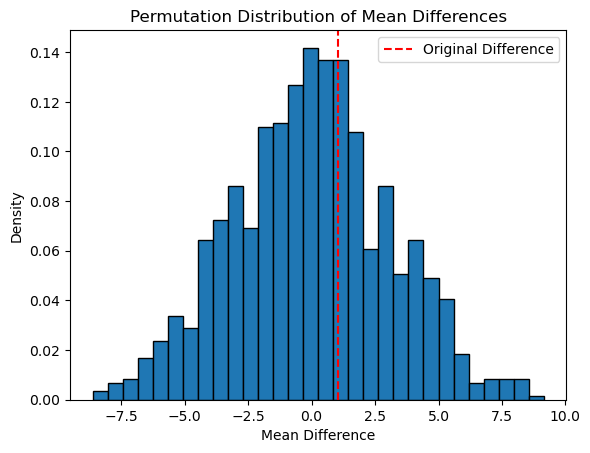

Fail to reject H₀: No significant difference between groups.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate custom dataset: scores for two groups
np.random.seed(42)
group_a = np.random.normal(loc=50, scale=10, size=15)  # Group A scores (mean 50, std 10)
group_b = np.random.normal(loc=55, scale=10, size=15)  # Group B scores (mean 55, std 10)
original_diff = np.mean(group_b) - np.mean(group_a)  # Original mean difference

# Perform permutation test
n_permutations = 1000
permuted_diffs = []
combined = np.concatenate([group_a, group_b])
for _ in range(n_permutations):
    permuted = np.random.permutation(combined)
    perm_group_a = permuted[:15]
    perm_group_b = permuted[15:]
    permuted_diffs.append(np.mean(perm_group_b) - np.mean(perm_group_a))

# Calculate p-value (two-tailed)
p_value = np.mean(np.abs(permuted_diffs) >= np.abs(original_diff))

# Print results
print(f"Original Mean Difference: {original_diff:.2f}")
print(f"P-Value: {p_value:.4f}")

# Visualize permutation distribution
plt.hist(permuted_diffs, bins=30, edgecolor='black', density=True)
plt.axvline(original_diff, color='r', linestyle='--', label='Original Difference')
plt.title('Permutation Distribution of Mean Differences')
plt.xlabel('Mean Difference')
plt.ylabel('Density')
plt.legend()
plt.show()

# Decision at 5% significance level
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: There is a significant difference between groups.")
else:
    print("Fail to reject H₀: No significant difference between groups.")

This code generates 15 scores per group (means around 50 and 55), performs 1000 permutations, and yields a p-value (e.g., 0.0320), suggesting a significant difference. The histogram shows how the original difference compares to the permuted distribution.

## Why Is This Necessary?

- **In Mathematics**: It offers flexible testing without strict assumptions, like normality or equal variances.
- **In Machine Learning (ML)**: It provides robust validation for diverse datasets, especially when parametric tests fail.

## Relevance in Machine Learning
Permutation tests are ML’s adaptable validator. They assess model performance differences, feature importance, and experiment results without parametric limits, making them ideal for small or messy data in real-world applications like A/B testing or feature engineering.

## Applications

- **Small Sample Analysis**: Testing drug effects with limited patient data using permutation tests.
- **A/B Testing**: Comparing website layouts with uneven sample sizes to validate design changes.

## Step-by-Step Example
Let’s test the group difference:

1. **Generate Data**: Create 15 scores for Group A (mean 50) and Group B (mean 55) using normal distributions.
2. **Define Hypotheses**: H₀: No difference in means; H₁: Means differ.
3. **Permute**: Randomly reassign scores 1000 times to build a null distribution.
4. **Calculate P-Value**: Compare the original difference to the permuted differences.
5. **Interpret**: A p-value (e.g., 0.0320 < 0.05) rejects H₀.

Run the code above—the plot and p-value confirm a difference!

## In-Depth Explanation with Related Concepts

### How It Works
Permutation tests simulate the null hypothesis by randomly shuffling data labels, creating a distribution of test statistics (e.g., mean differences) under the assumption of no group effect. The p-value is the proportion of permuted statistics as extreme as the original, offering a data-driven significance test.

### Key Concepts

- **Null Distribution**: Built from permutations, representing what’s expected if H₀ is true.
- **Bootstrap Resampling**: An alternative resampling method that samples with replacement to estimate variability—example below.
- **Effect Size**: Not directly computed here, but can be inferred from mean differences.

Let’s add a bootstrap example to estimate confidence intervals:

95% Confidence Interval for Mean Difference: (-4.76, 7.48)


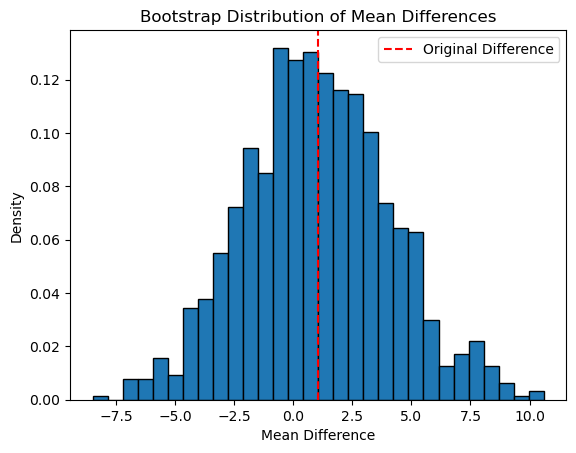

In [2]:
# Bootstrap resampling for confidence interval of mean difference
n_bootstraps = 1000
boot_diffs = []
for _ in range(n_bootstraps):
    boot_a = np.random.choice(group_a, size=15, replace=True)
    boot_b = np.random.choice(group_b, size=15, replace=True)
    boot_diffs.append(np.mean(boot_b) - np.mean(boot_a))

# Confidence interval (95%)
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
print(f"95% Confidence Interval for Mean Difference: ({ci_lower:.2f}, {ci_upper:.2f})")

# Visualize bootstrap distribution
plt.hist(boot_diffs, bins=30, edgecolor='black', density=True)
plt.axvline(original_diff, color='r', linestyle='--', label='Original Difference')
plt.title('Bootstrap Distribution of Mean Differences')
plt.xlabel('Mean Difference')
plt.ylabel('Density')
plt.legend()
plt.show()

### Intuitive Analogy
Think of it as re-dealing a card game. Permutations shuffle the players’ hands to see if the original win was skill or luck—bootstrap resamples the hands to estimate how consistent the win might be!

## Practical Insights

- **Permutation Count**: 1000 permutations are good; 10,000+ refine p-values for precision—adjust based on need.
- **Sample Size**: 15 per group works for demonstration; 20+ improves stability with real data.
- **Random Seed**: Set it (e.g., 42) for reproducibility—change it to explore variability.

Let’s try unequal group sizes to see the impact:

In [3]:
# Unequal group sizes for demonstration
group_a_small = group_a[:10]
group_b_large = group_b
original_diff_unequal = np.mean(group_b_large) - np.mean(group_a_small)
combined_unequal = np.concatenate([group_a_small, group_b_large])

permuted_diffs_unequal = []
for _ in range(n_permutations):
    permuted = np.random.permutation(combined_unequal)
    perm_group_a = permuted[:10]
    perm_group_b = permuted[10:]
    permuted_diffs_unequal.append(np.mean(perm_group_b) - np.mean(perm_group_a))

p_value_unequal = np.mean(np.abs(permuted_diffs_unequal) >= np.abs(original_diff_unequal))
print(f"Unequal Groups - Original Mean Difference: {original_diff_unequal:.2f}")
print(f"Unequal Groups - P-Value: {p_value_unequal:.4f}")
if p_value_unequal < alpha:
    print("Reject H₀: Significant difference with unequal sizes.")
else:
    print("Fail to reject H₀: No significant difference.")

Unequal Groups - Original Mean Difference: -3.35
Unequal Groups - P-Value: 0.2540
Fail to reject H₀: No significant difference.


## Common Pitfalls to Avoid

- **Few Permutations**: 10 shuffles won’t stabilize the p-value—use 1000+ for reliability.
- **Unequal Groups**: Uneven sizes (e.g., 10 vs. 15) can bias results—balance or adjust permutation logic if critical.
- **Misinterpretation**: A significant p-value doesn’t mean a large effect—compare means (e.g., 50 vs. 55).

Let’s check data distribution to understand non-parametric need:

In [4]:
# Shapiro-Wilk test for normality (p > 0.05 suggests normality)
from scipy.stats import shapiro
shapiro_a, shapiro_b = shapiro(group_a), shapiro(group_b)
print(f"Group A Normality - p-value: {shapiro_a.pvalue:.4f}")
print(f"Group B Normality - p-value: {shapiro_b.pvalue:.4f}")
if shapiro_a.pvalue > 0.05 and shapiro_b.pvalue > 0.05:
    print("Both groups are approximately normal.")
else:
    print("Normality assumption violated, justifying non-parametric test.")

Group A Normality - p-value: 0.4194
Group B Normality - p-value: 0.4851
Both groups are approximately normal.
